# Day 3 – Forecasting Data Preparation

## Objective

The objective of Day 3 is to prepare the Superstore sales dataset for time series forecasting.

This includes creating daily, weekly, and monthly sales datasets, checking date continuity, handling missing dates, and saving forecasting-ready files for model building.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
df = pd.read_csv("../data/processed/superstore_sales_processed.csv")

print("Dataset loaded successfully.")
print(df.shape)

df.head()

Dataset loaded successfully.
(9800, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn


In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

print(df["Order Date"].dtype)

datetime64[us]


In [15]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [16]:
print("Number of days :", len(daily_sales))

print("\nFirst Date :", daily_sales["Order Date"].min())

print("Last Date :", daily_sales["Order Date"].max())

Number of days : 1230

First Date : 2015-01-03 00:00:00
Last Date : 2018-12-30 00:00:00


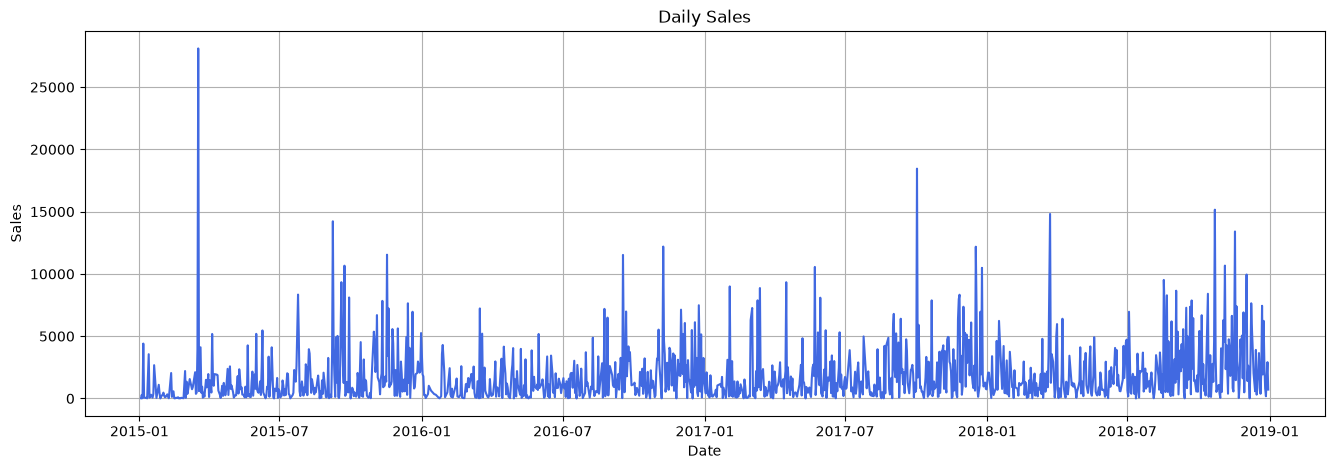

In [17]:
plt.figure(figsize=(16,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"],
    color="royalblue"
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [18]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [19]:
print("Number of Weeks :", len(weekly_sales))

print("\nFirst Week :", weekly_sales["Order Date"].min())

print("Last Week :", weekly_sales["Order Date"].max())

Number of Weeks : 209

First Week : 2015-01-04 00:00:00
Last Week : 2018-12-30 00:00:00


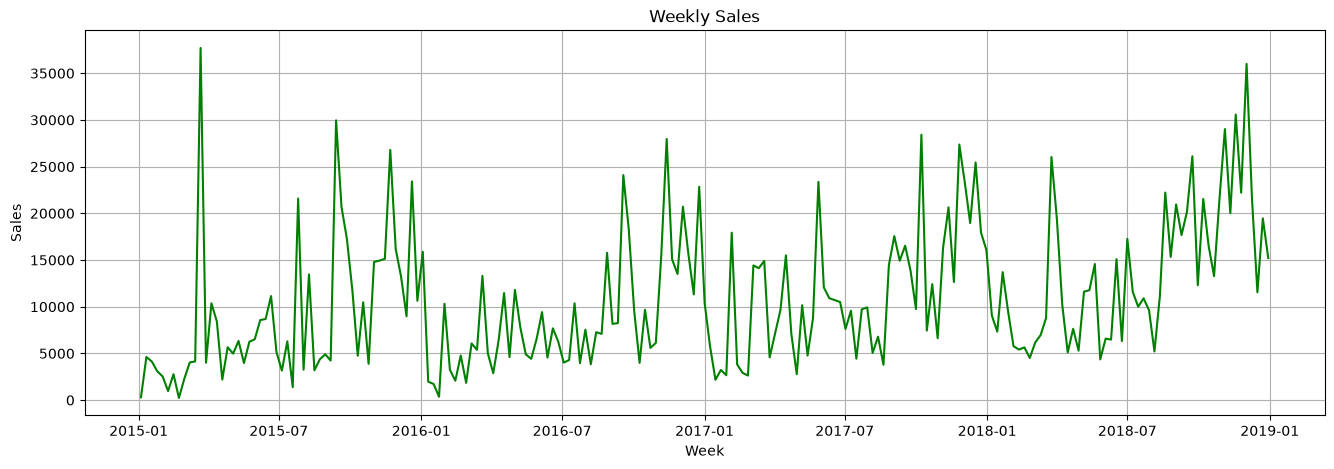

In [20]:
plt.figure(figsize=(16,5))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="green"
)

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [24]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [25]:
print("Number of Months :", len(monthly_sales))

print("\nFirst Month :", monthly_sales["Order Date"].min())

print("Last Month :", monthly_sales["Order Date"].max())

Number of Months : 48

First Month : 2015-01-31 00:00:00
Last Month : 2018-12-31 00:00:00


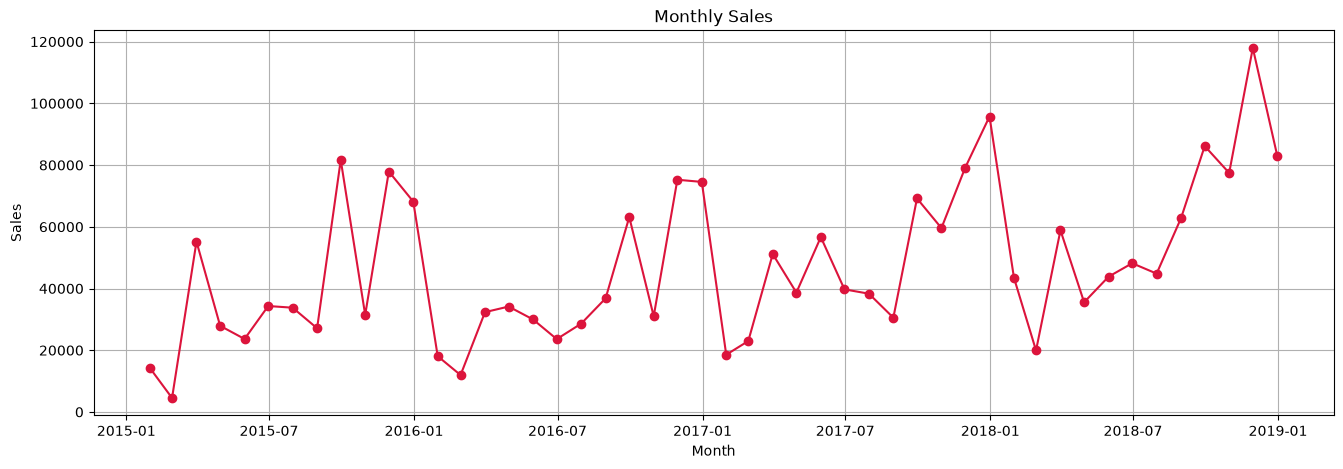

In [26]:
plt.figure(figsize=(16,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    color="crimson",
    marker="o"
)

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [27]:
daily_sales.to_csv("../data/processed/daily_sales.csv", index=False)
weekly_sales.to_csv("../data/processed/weekly_sales.csv", index=False)
monthly_sales.to_csv("../data/processed/monthly_sales.csv", index=False)

print("Daily, weekly, and monthly sales datasets saved successfully.")

Daily, weekly, and monthly sales datasets saved successfully.


# Day 3 Summary

## Objective

The objective of Day 3 was to prepare sales data for forecasting by creating time-based sales datasets.

---

## Tasks Completed

- Loaded the processed Superstore sales dataset.
- Converted Order Date into datetime format.
- Created daily sales dataset.
- Created weekly sales dataset.
- Created monthly sales dataset.
- Visualized daily, weekly, and monthly sales trends.
- Saved forecasting-ready datasets.

---

## Output Files

- data/processed/daily_sales.csv
- data/processed/weekly_sales.csv
- data/processed/monthly_sales.csv

---

## Outcome

The sales data is now ready for time series forecasting models in the next stage.